# Plots for every Target Game

PD target, lambda = 2

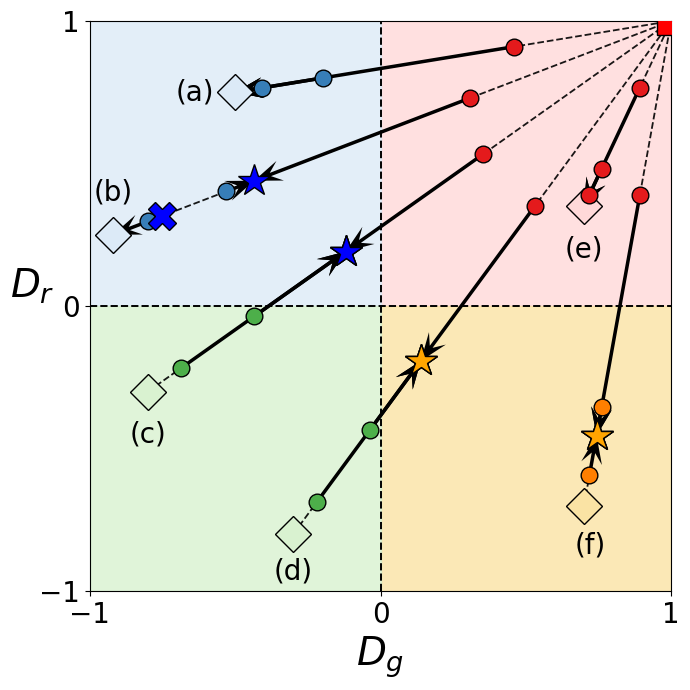

Running (a)  D_g=-0.5, D_r=0.75, ρ₀=0.25
Running (a)  D_g=-0.5, D_r=0.75, ρ₀=0.45
Running (a)  D_g=-0.5, D_r=0.75, ρ₀=0.80
Running (b)  D_g=-0.92, D_r=0.25, ρ₀=0.25
Running (b)  D_g=-0.92, D_r=0.25, ρ₀=0.45
Running (b)  D_g=-0.92, D_r=0.25, ρ₀=0.80
Running (c)  D_g=-0.8, D_r=-0.3, ρ₀=0.25
Running (c)  D_g=-0.8, D_r=-0.3, ρ₀=0.45
Running (c)  D_g=-0.8, D_r=-0.3, ρ₀=0.80
Running (d)  D_g=-0.3, D_r=-0.8, ρ₀=0.25
Running (d)  D_g=-0.3, D_r=-0.8, ρ₀=0.45
Running (d)  D_g=-0.3, D_r=-0.8, ρ₀=0.80
Running (e)  D_g=0.7, D_r=0.35, ρ₀=0.25
Running (e)  D_g=0.7, D_r=0.35, ρ₀=0.45
Running (e)  D_g=0.7, D_r=0.35, ρ₀=0.80
Running (f)  D_g=0.7, D_r=-0.7, ρ₀=0.25
Running (f)  D_g=0.7, D_r=-0.7, ρ₀=0.45
Running (f)  D_g=0.7, D_r=-0.7, ρ₀=0.80


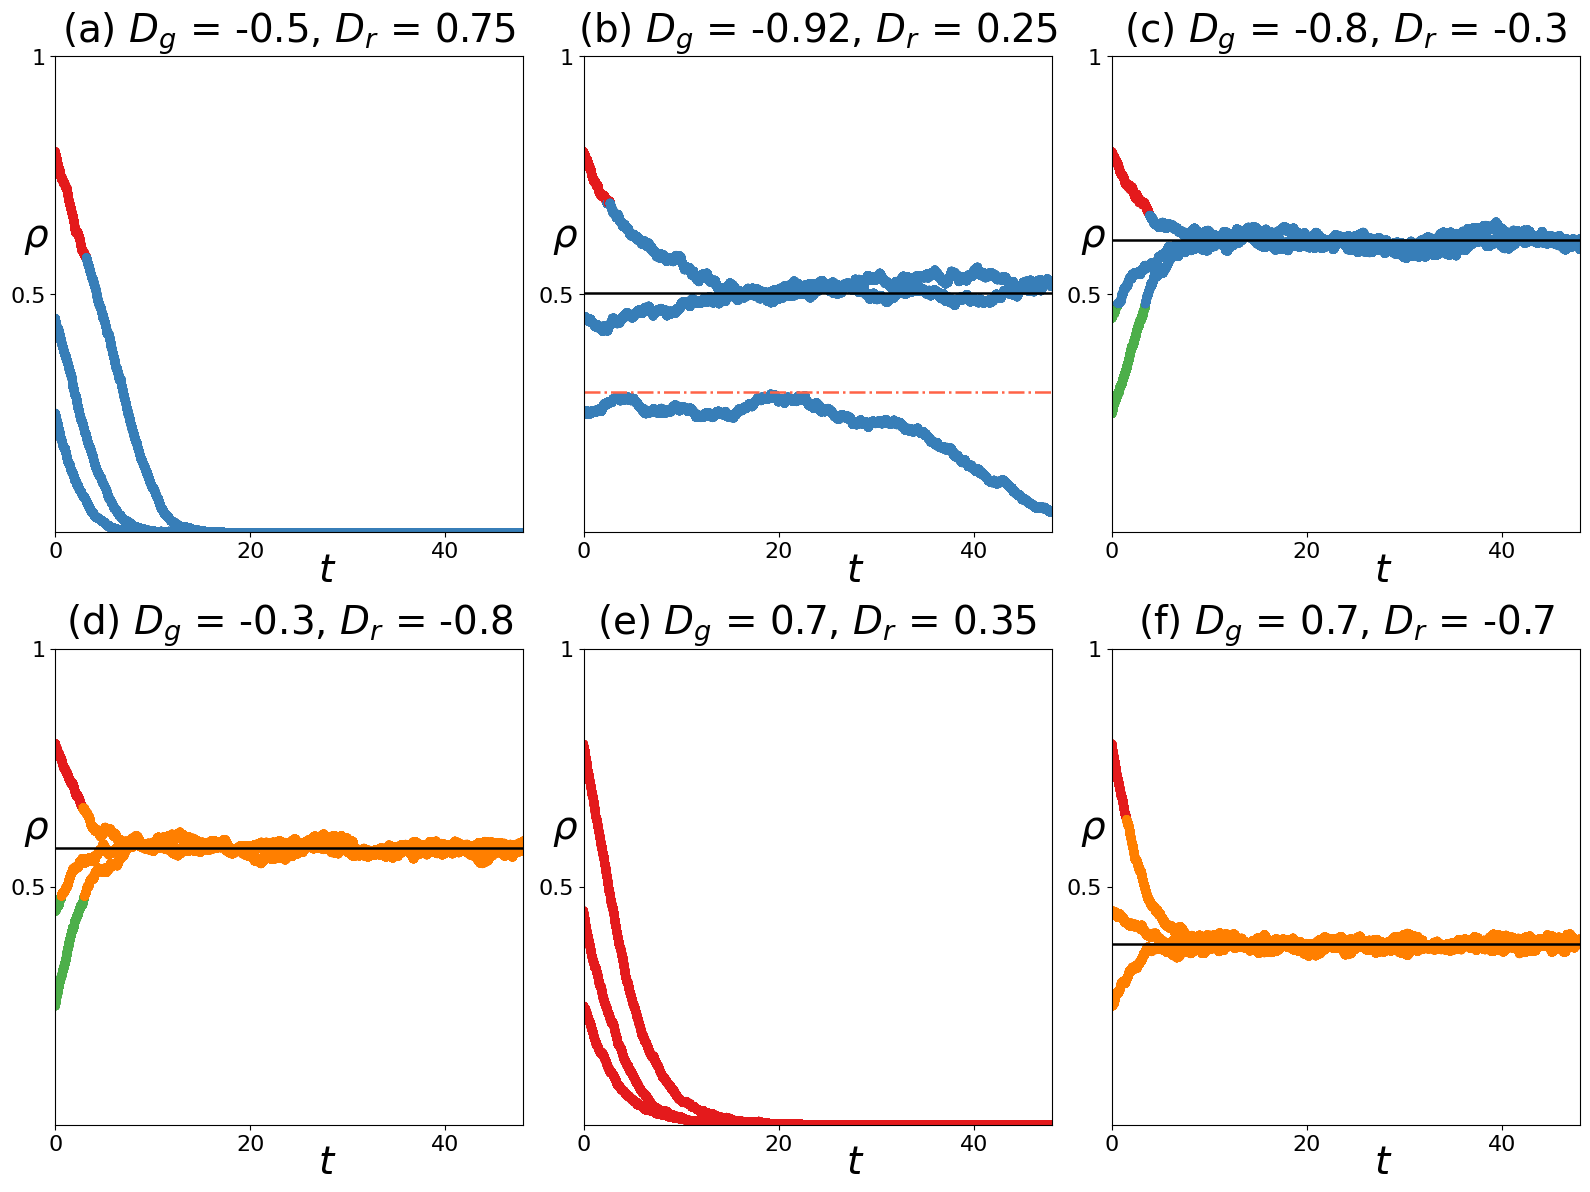

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = 1
Dg_arrival = 1
lambda_val = 2

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

# base_points = [
#     (-0.92, 0.25),   # (a)
#     (-0.3, -0.8),   # (b)
#     (0.7, -0.7),    # (c)
#     (-0.5, 0.75),   # (d)
#     (0.7, 0.35),   # (e)
#     (-0.8, -0.3),   # (f)
# ]

base_points = [
    (-0.5, 0.75),
    (-0.92, 0.25),
    (-0.8, -0.3),
    (-0.3, -0.8),
    (0.7, 0.35),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_positions = [(-0.64, 0.75), (-0.92, 0.4), (-0.80, -0.45), (-0.30, -0.93), (0.7, 0.2), (0.72, -0.84)]
# panel_positions = [(-0.92, 0.4), (-0.30, -0.93), (0.72, -0.84), (-0.64, 0.75), (0.7, 0.2), (-0.80, -0.45)]

initial_cooperator_fractions = [0.25, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction


# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff diff at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                          angles='xy', scale_units='xy', scale=1,
                          headwidth=6, headlength=8, headaxislength=5,
                          color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 3, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)

plt.tight_layout()
plt.show()

PD target, lambda = 1

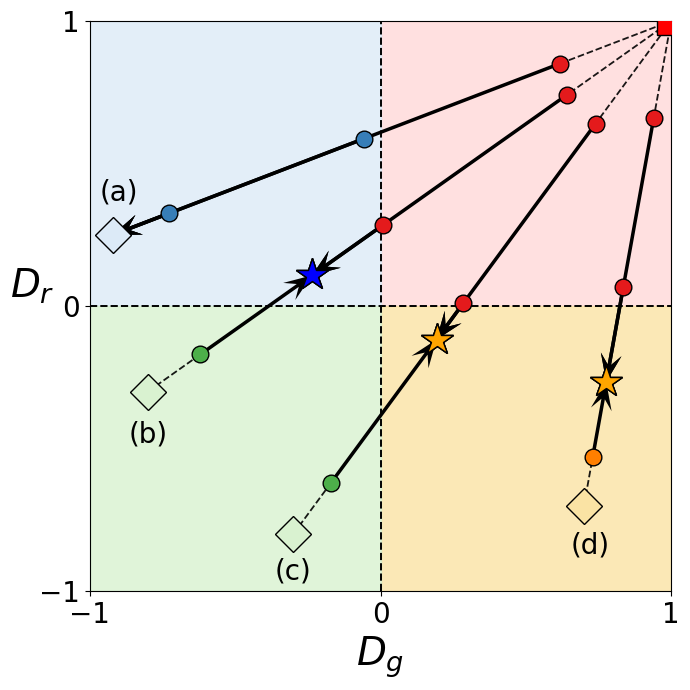

Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.10
Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.45
Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.80
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.10
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.45
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.80
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.10
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.45
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.80
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.10
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.45
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.80


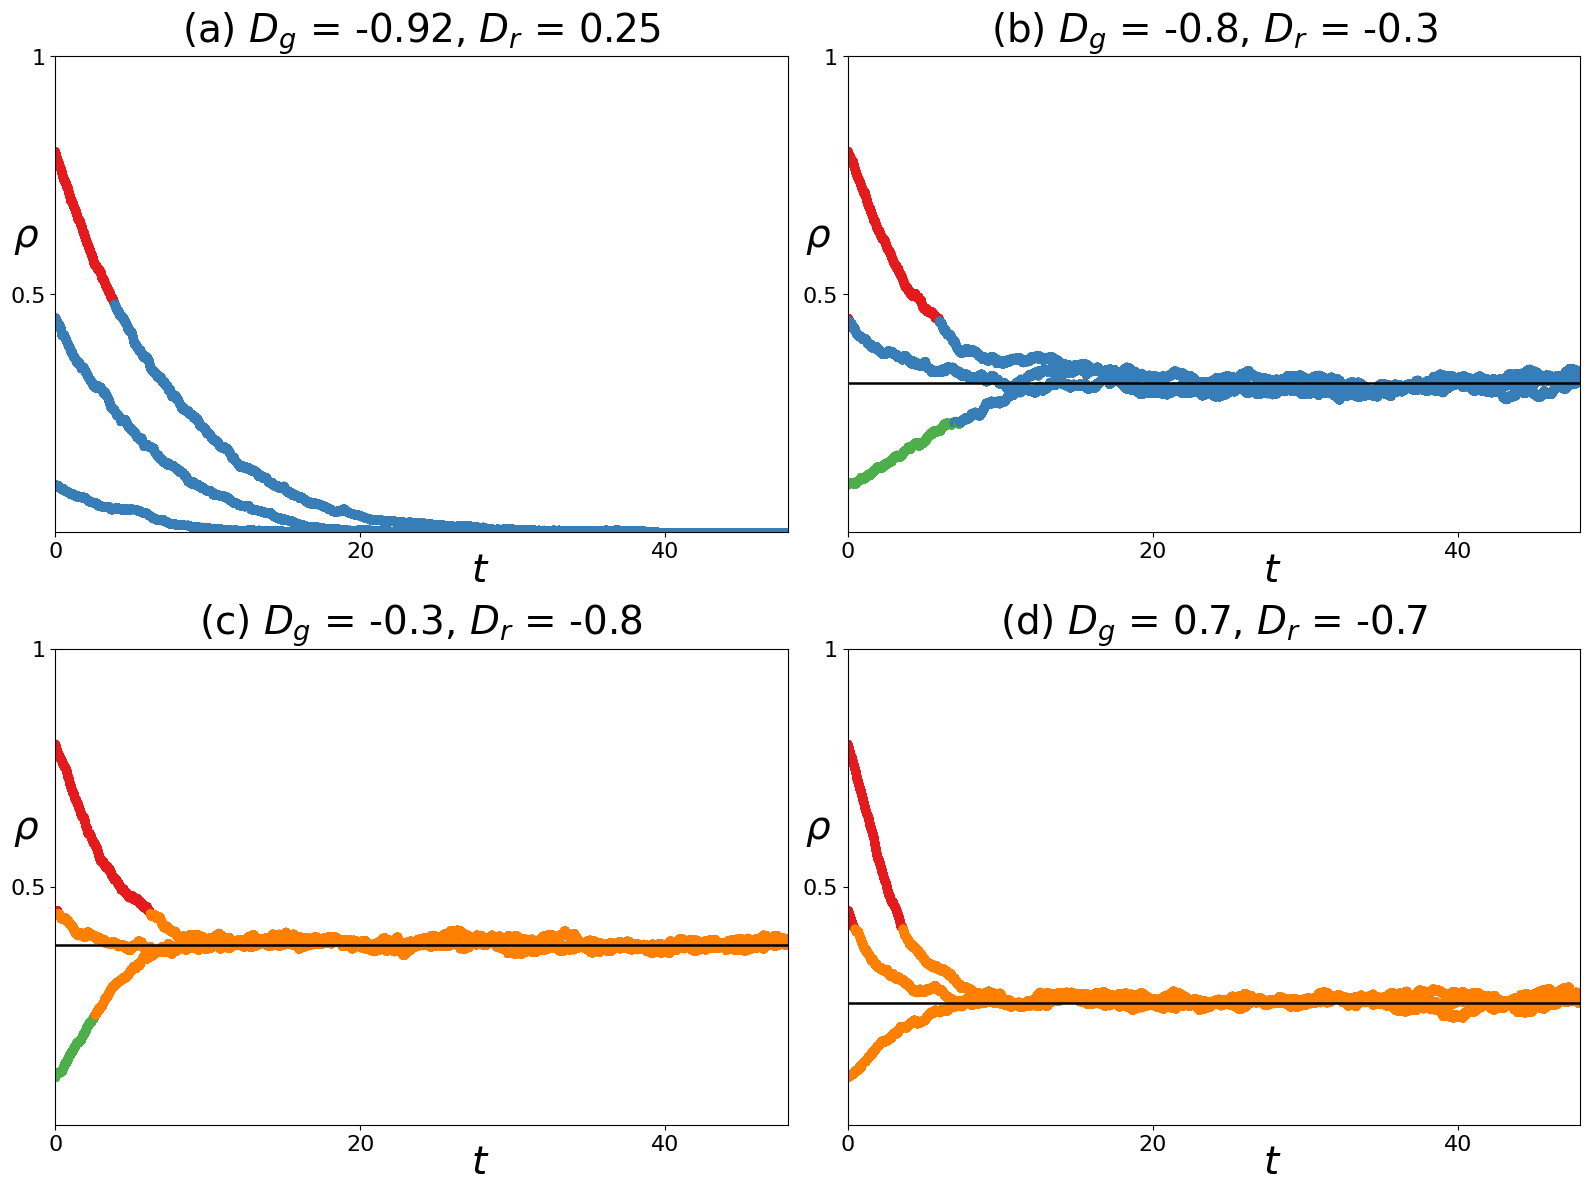

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = 1
Dg_arrival = 1
lambda_val = 1

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.92, 0.25),
    (-0.8, -0.3),
    (-0.3, -0.8),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.9, 0.4), (-0.80, -0.45), (-0.30, -0.93), (0.72, -0.84)]

initial_cooperator_fractions = [0.1, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use derivative sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                          angles='xy', scale_units='xy', scale=1,
                          headwidth=6, headlength=8, headaxislength=5,
                          color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)


plt.tight_layout()
plt.show()

PD target lambda=0.5

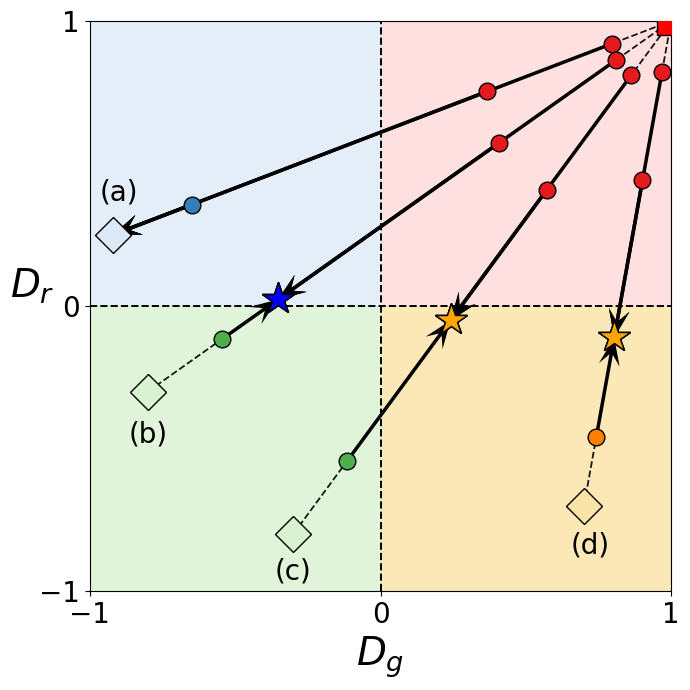

Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.02
Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.45
Running (a)  D_g=-0.92, D_r=0.25, ρ₀=0.80
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.02
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.45
Running (b)  D_g=-0.8, D_r=-0.3, ρ₀=0.80
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.02
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.45
Running (c)  D_g=-0.3, D_r=-0.8, ρ₀=0.80
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.02
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.45
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.80


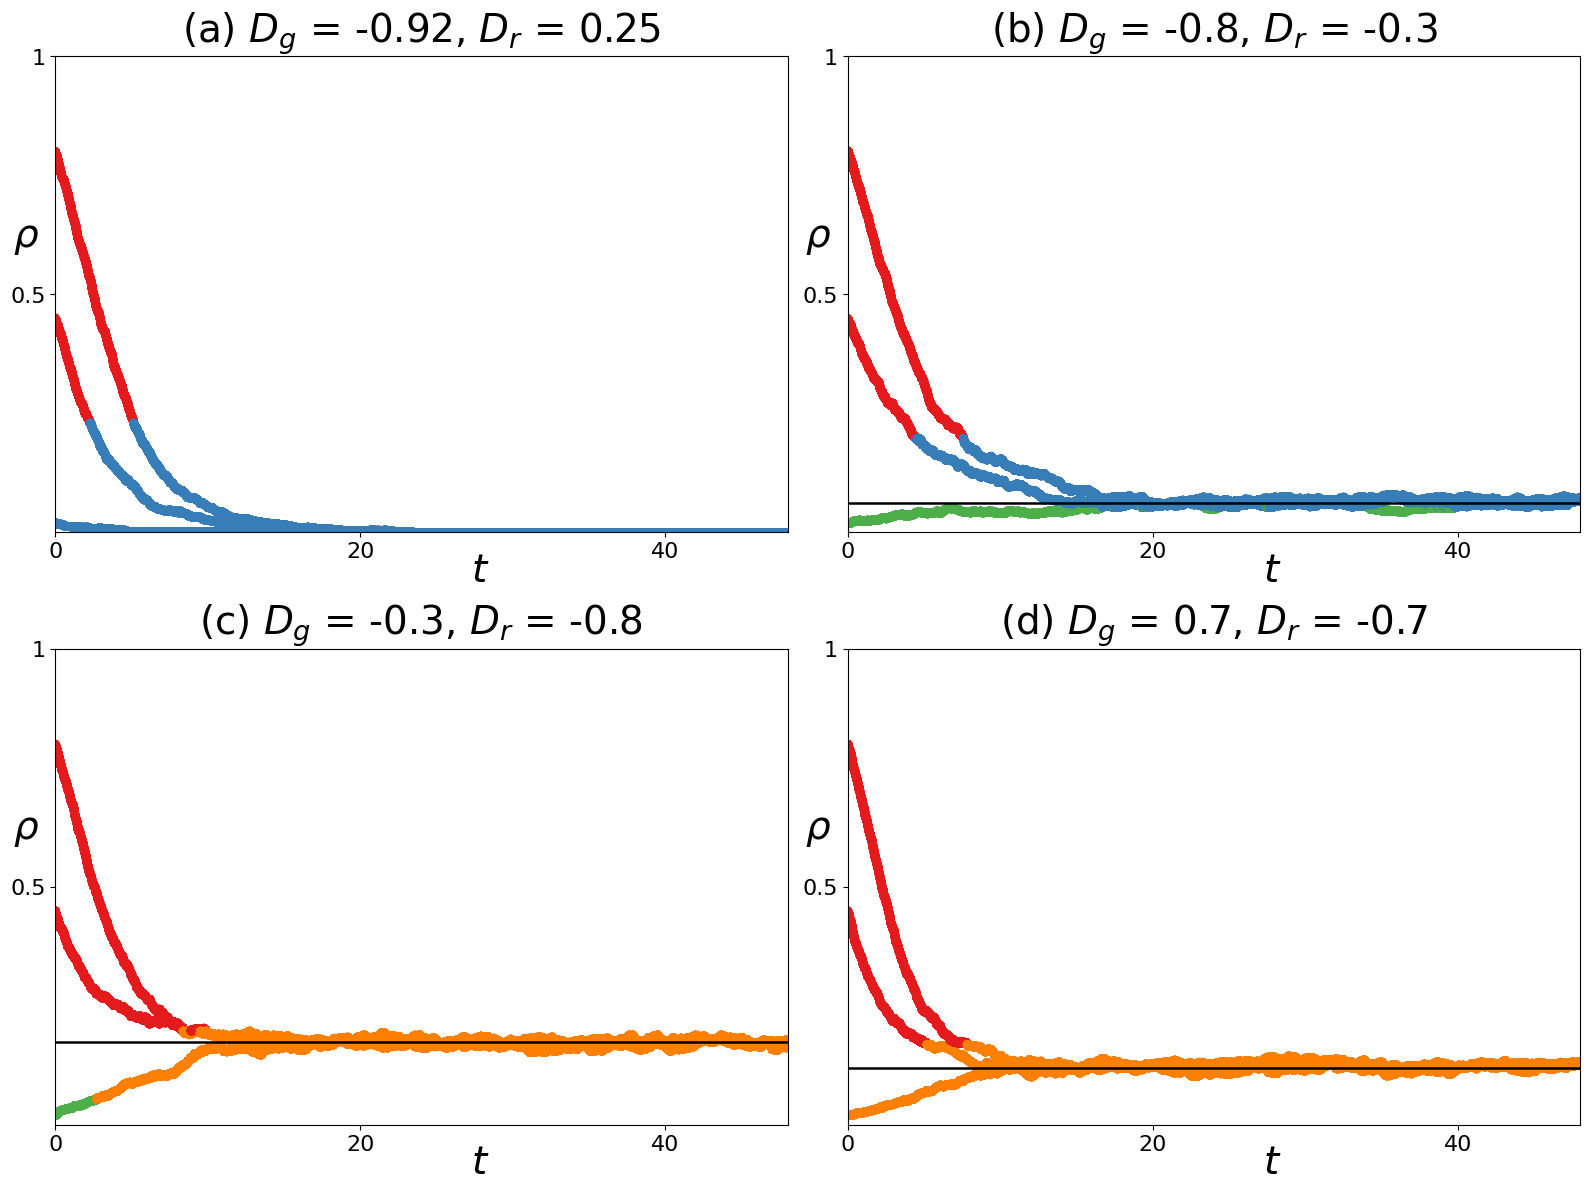

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = 1
Dg_arrival = 1
lambda_val = 0.5

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.92, 0.25),
    (-0.8, -0.3),
    (-0.3, -0.8),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.9, 0.4), (-0.80, -0.45), (-0.30, -0.93), (0.72, -0.84)]

initial_cooperator_fractions = [0.02, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use derivative sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                          angles='xy', scale_units='xy', scale=1,
                          headwidth=6, headlength=8, headaxislength=5,
                          color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)


plt.tight_layout()
plt.show()

HG target, lambda = 2

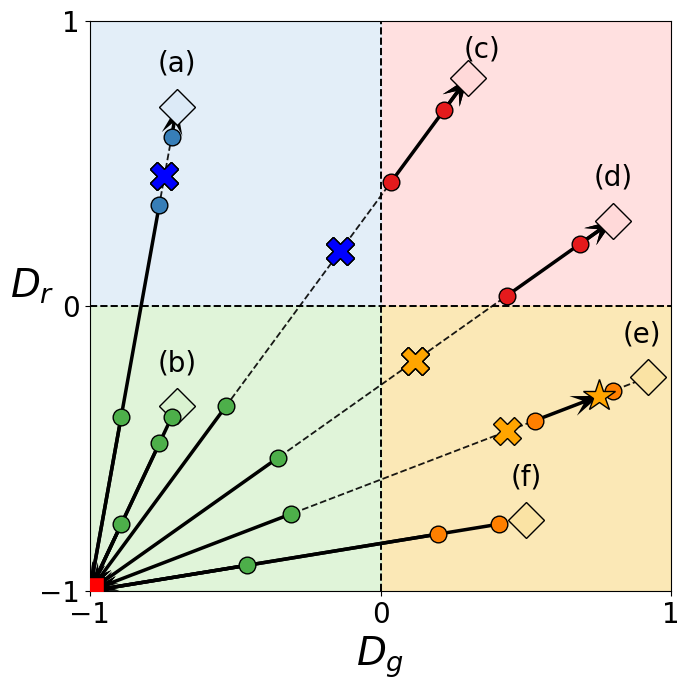

Running (a)  D_g=-0.7, D_r=0.7, ρ₀=0.25
Running (a)  D_g=-0.7, D_r=0.7, ρ₀=0.45
Running (a)  D_g=-0.7, D_r=0.7, ρ₀=0.80
Running (b)  D_g=-0.7, D_r=-0.35, ρ₀=0.25
Running (b)  D_g=-0.7, D_r=-0.35, ρ₀=0.45
Running (b)  D_g=-0.7, D_r=-0.35, ρ₀=0.80
Running (c)  D_g=0.3, D_r=0.8, ρ₀=0.25
Running (c)  D_g=0.3, D_r=0.8, ρ₀=0.45
Running (c)  D_g=0.3, D_r=0.8, ρ₀=0.80
Running (d)  D_g=0.8, D_r=0.3, ρ₀=0.25
Running (d)  D_g=0.8, D_r=0.3, ρ₀=0.45
Running (d)  D_g=0.8, D_r=0.3, ρ₀=0.80
Running (e)  D_g=0.92, D_r=-0.25, ρ₀=0.25
Running (e)  D_g=0.92, D_r=-0.25, ρ₀=0.45
Running (e)  D_g=0.92, D_r=-0.25, ρ₀=0.80
Running (f)  D_g=0.5, D_r=-0.75, ρ₀=0.25
Running (f)  D_g=0.5, D_r=-0.75, ρ₀=0.45
Running (f)  D_g=0.5, D_r=-0.75, ρ₀=0.80


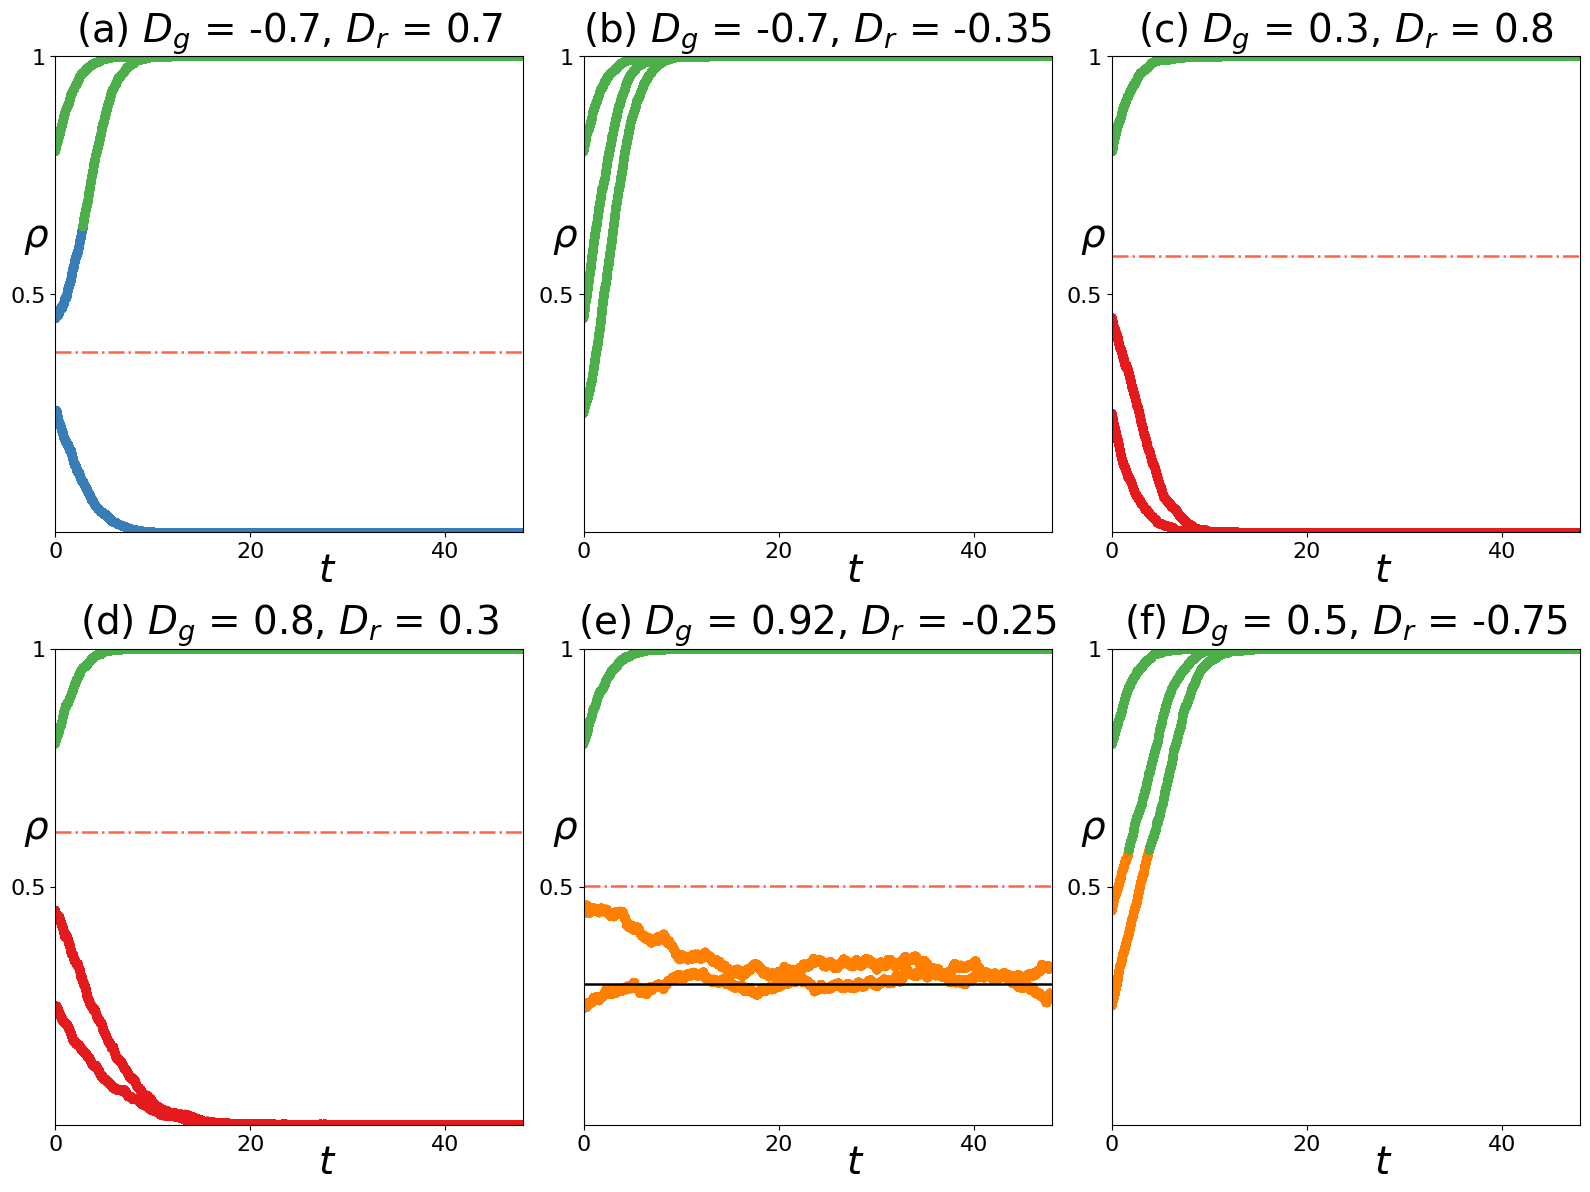

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = -1
Dg_arrival = -1
lambda_val = 2

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.7, 0.7),
    (-0.7, -0.35),
    (0.3, 0.8),
    (0.8, 0.3),
    (0.92, -0.25),
    (0.5, -0.75)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_positions = [(-0.7, 0.85), (-0.7, -0.2), (0.35, 0.9), (0.8, 0.45), (0.9, -0.1), (0.5, -0.6)]

initial_cooperator_fractions = [0.25, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff difference sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 3, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)


plt.tight_layout()
plt.show()

HG target, lambda = 1

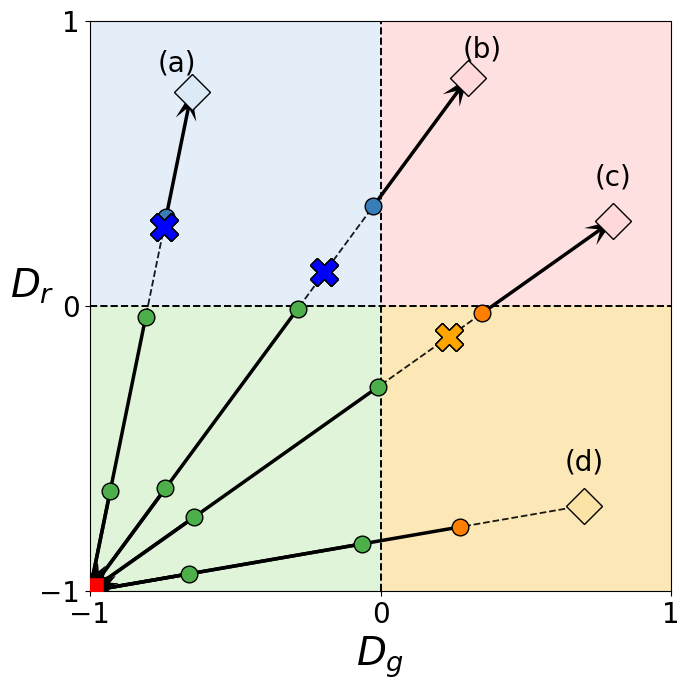

Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.25
Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.45
Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.80
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.25
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.45
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.80
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.25
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.45
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.80
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.25
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.45
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.80


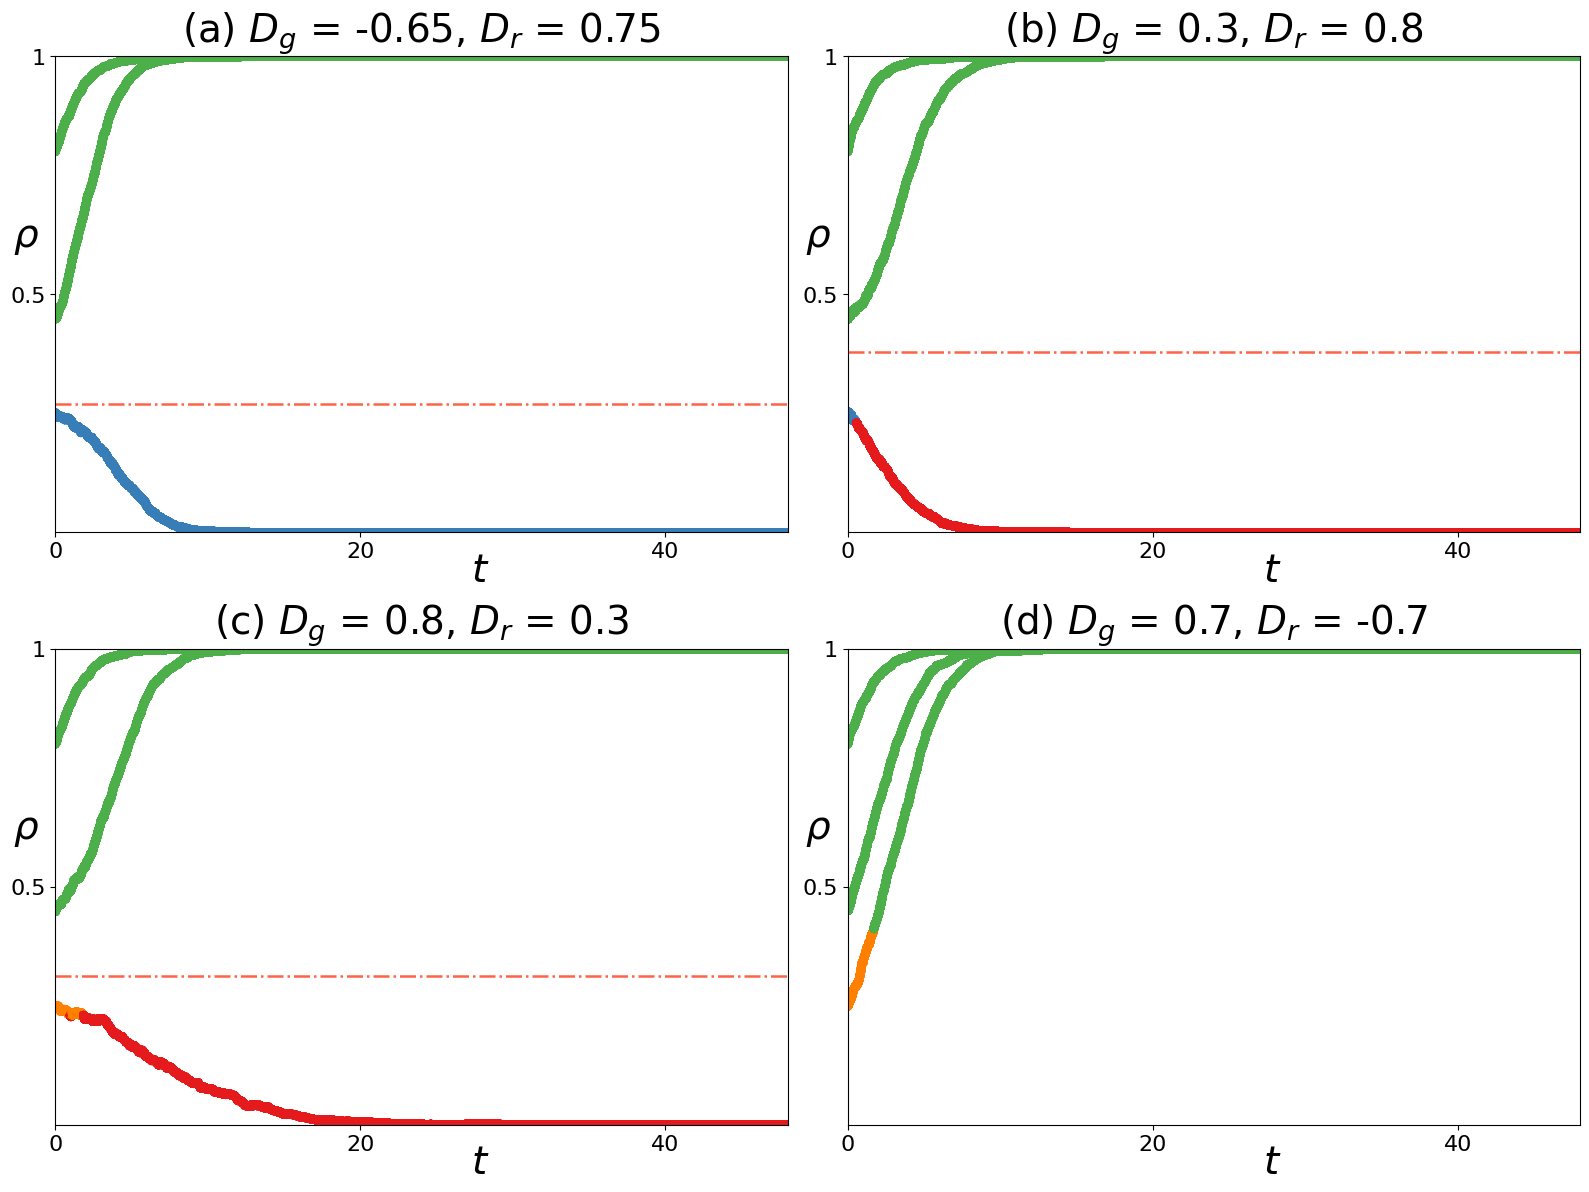

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = -1
Dg_arrival = -1
lambda_val = 1

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.65, 0.75),
    (0.3, 0.8),
    (0.8, 0.3),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.7, 0.85), (0.35, 0.9), (0.8, 0.45), (0.7, -0.55)]

initial_cooperator_fractions = [0.25, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff difference sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                # derivative > 0 → rho grows → system moves toward (Dg_arrival, Dr_arrival)
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)


plt.tight_layout()
plt.show()

HG target, lambda = 0.5

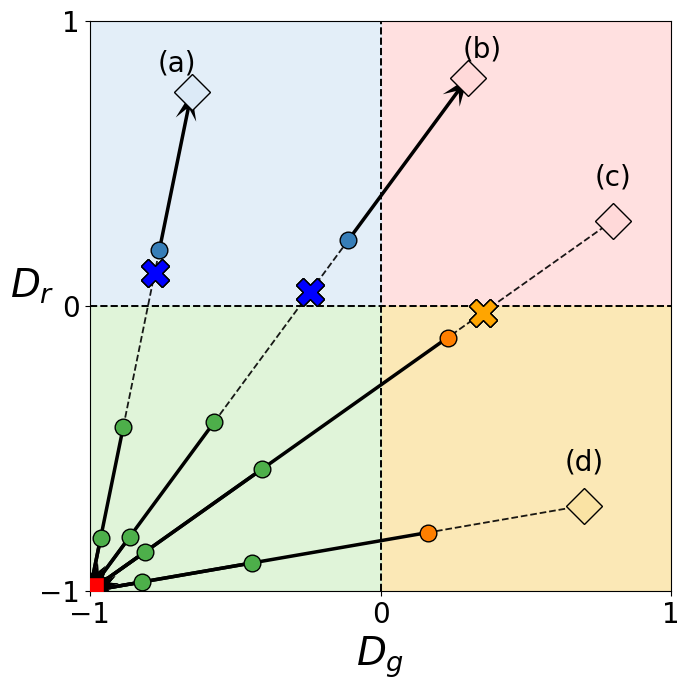

Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.10
Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.45
Running (a)  D_g=-0.65, D_r=0.75, ρ₀=0.80
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.10
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.45
Running (b)  D_g=0.3, D_r=0.8, ρ₀=0.80
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.10
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.45
Running (c)  D_g=0.8, D_r=0.3, ρ₀=0.80
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.10
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.45
Running (d)  D_g=0.7, D_r=-0.7, ρ₀=0.80


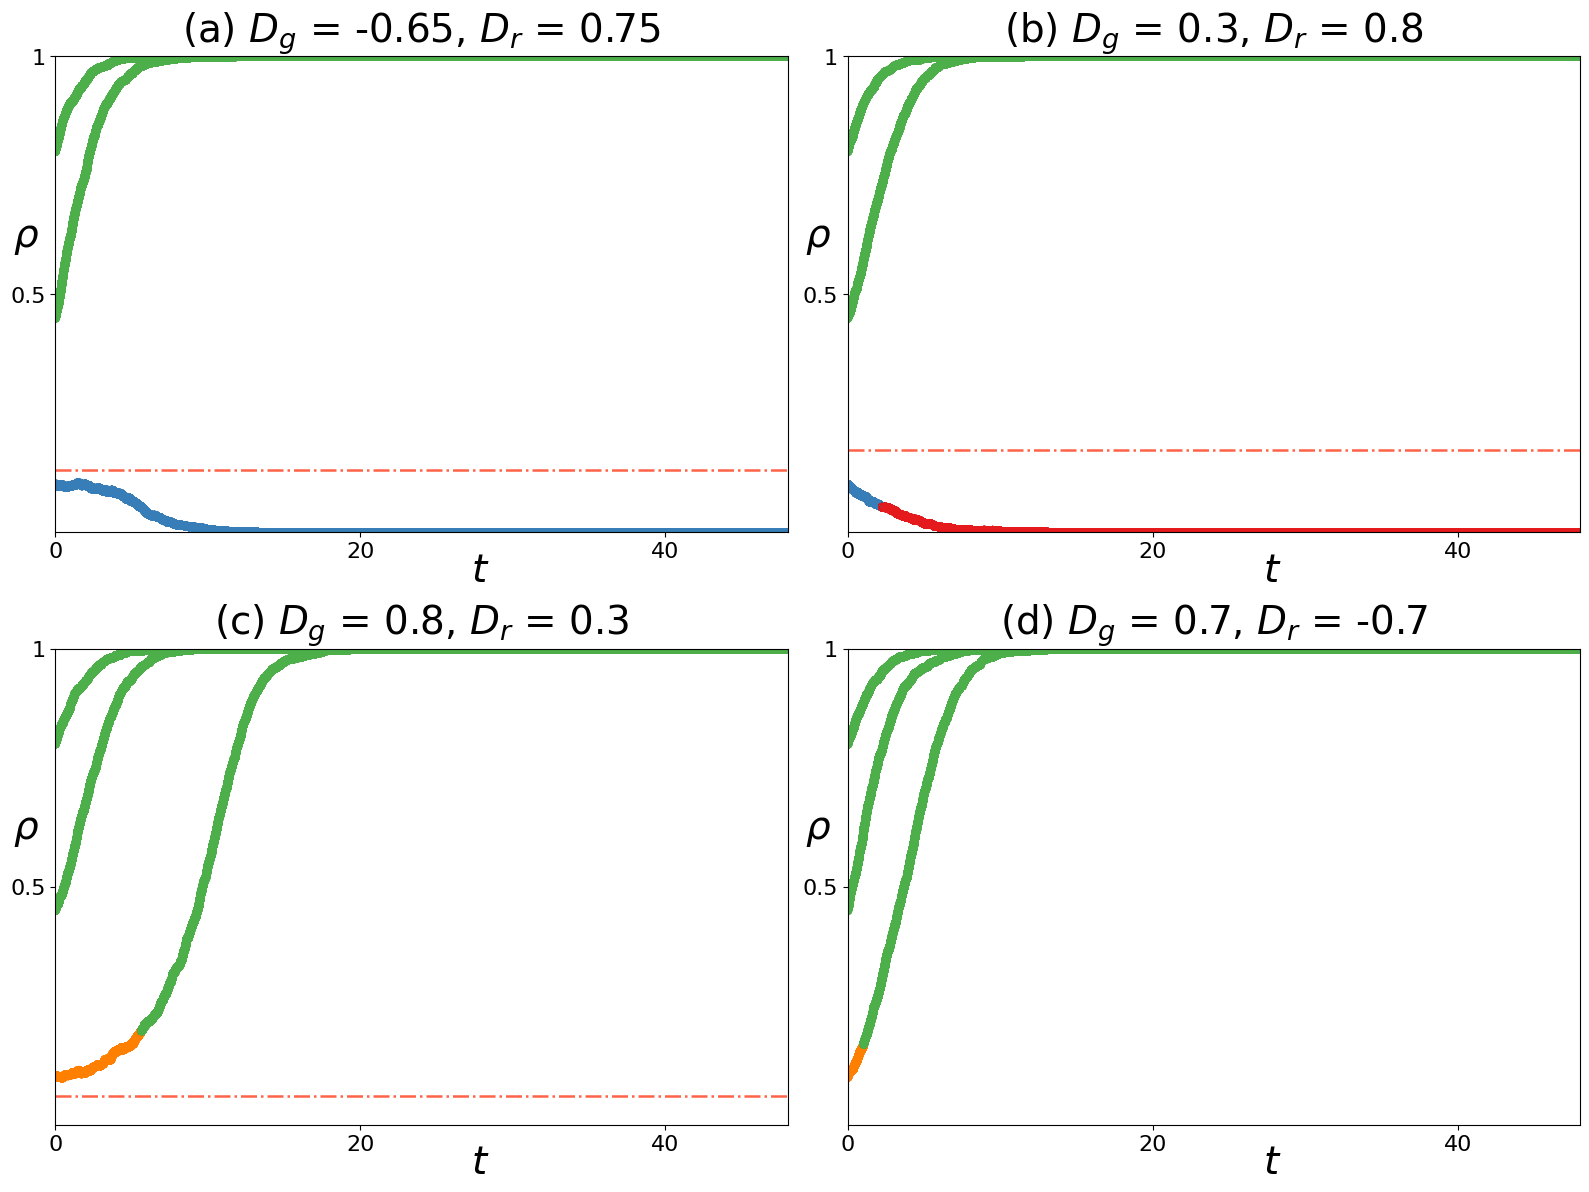

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = -1
Dg_arrival = -1
lambda_val = 0.5

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.65, 0.75),
    (0.3, 0.8),
    (0.8, 0.3),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.7, 0.85), (0.35, 0.9), (0.8, 0.45), (0.7, -0.55)]

initial_cooperator_fractions = [0.1, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff difference sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                # derivative > 0 → rho grows → system moves toward (Dg_arrival, Dr_arrival)
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)

plt.tight_layout()
plt.show()

SD target game, lambda = 2

SD target game, lambda = 1

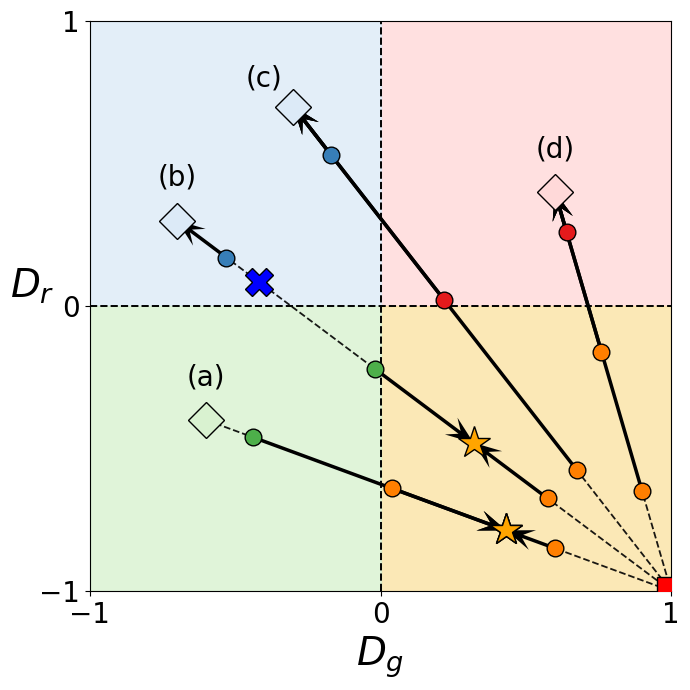

Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.10
Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.40
Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.75
Running (b)  D_g=-0.7, D_r=0.3, ρ₀=0.10
Running (b)  D_g=-0.7, D_r=0.3, ρ₀=0.40
Running (b)  D_g=-0.7, D_r=0.3, ρ₀=0.75
Running (c)  D_g=-0.3, D_r=0.7, ρ₀=0.10
Running (c)  D_g=-0.3, D_r=0.7, ρ₀=0.40
Running (c)  D_g=-0.3, D_r=0.7, ρ₀=0.75
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.10
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.40
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.75


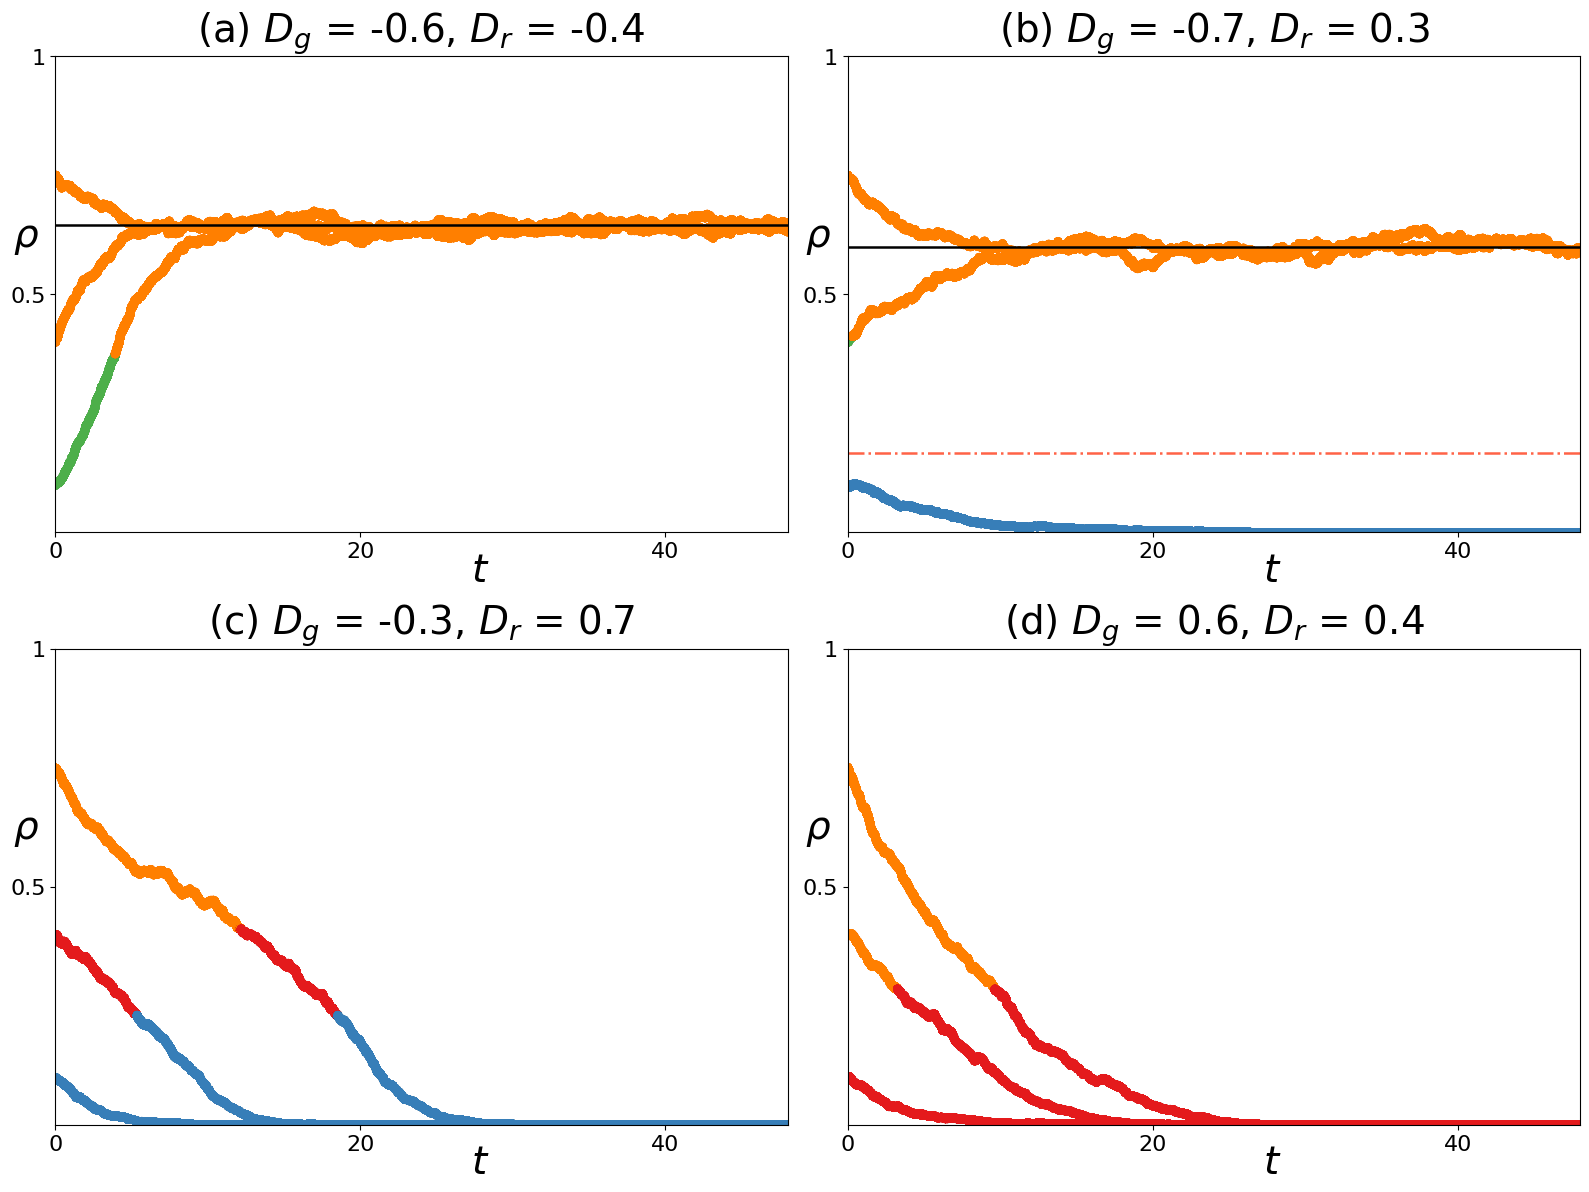

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = -1
Dg_arrival = 1
lambda_val = 1

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.6,-0.4),
    (-0.7, 0.3),
    (-0.3, 0.7),
    (0.6, 0.4)
]
# grid_vals = [-0.75, -0.25, 0.25, 0.75]
# base_points = [(Dg, Dr) for Dr in grid_vals for Dg in grid_vals]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.6, -0.25), (-0.7, 0.45), (-0.4, 0.8), (0.6, 0.55)]

initial_cooperator_fractions = [0.1, 0.4, 0.75]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff difference sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                # derivative > 0 → rho grows → system moves toward (Dg_arrival, Dr_arrival)
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx], fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)


plt.tight_layout()
plt.show()

SD target game, lambda=0.5

SH target game, lambda = 2

SH target game, lambda = 1

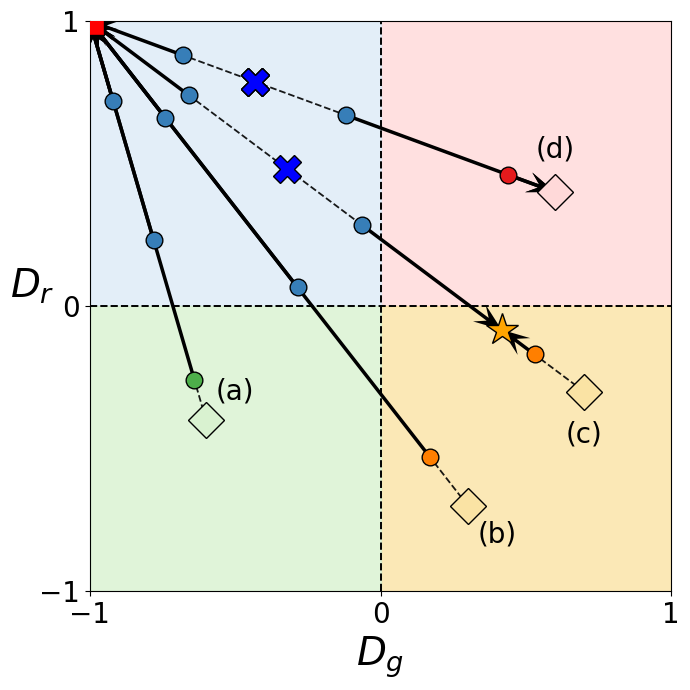

Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.10
Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.45
Running (a)  D_g=-0.6, D_r=-0.4, ρ₀=0.80
Running (b)  D_g=0.3, D_r=-0.7, ρ₀=0.10
Running (b)  D_g=0.3, D_r=-0.7, ρ₀=0.45
Running (b)  D_g=0.3, D_r=-0.7, ρ₀=0.80
Running (c)  D_g=0.7, D_r=-0.3, ρ₀=0.10
Running (c)  D_g=0.7, D_r=-0.3, ρ₀=0.45
Running (c)  D_g=0.7, D_r=-0.3, ρ₀=0.80
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.10
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.45
Running (d)  D_g=0.6, D_r=0.4, ρ₀=0.80


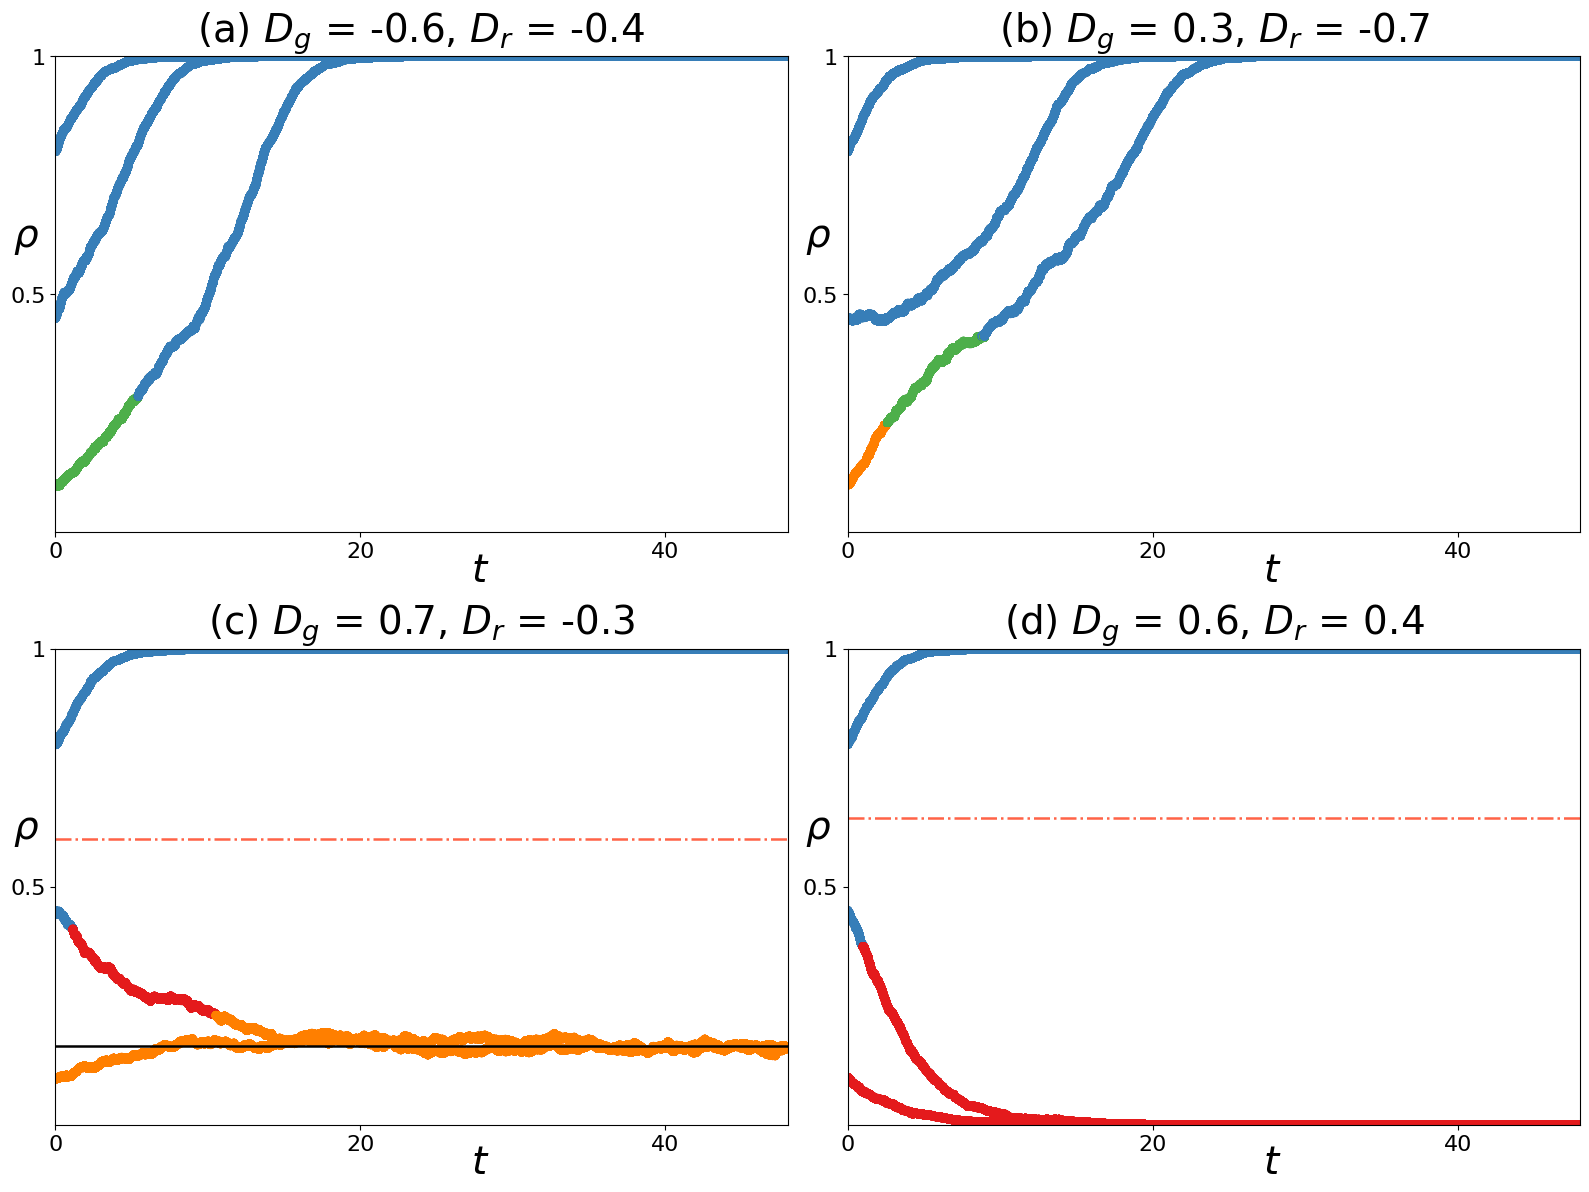

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = 1
Dg_arrival = -1
lambda_val = 1

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.6, -0.4),
    (0.3, -0.7),
    (0.7, -0.3),
    (0.6, 0.4)
]
# grid_vals = [-0.75, -0.25, 0.25, 0.75]
# base_points = [(Dg, Dr) for Dr in grid_vals for Dg in grid_vals]

panel_labels    = ['(a)', '(b)', '(c)', '(d)']
panel_positions = [(-0.5, -0.3), (0.4, -0.8), (0.7, -0.45), (0.6, 0.55)]

initial_cooperator_fractions = [0.1, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# SIMULATION HELPERS
# ============================================================
def initialize_population(N, initial_cooperator_fraction):
    num_cooperators = int(initial_cooperator_fraction * N)
    strategies = np.array(['C'] * num_cooperators + ['D'] * (N - num_cooperators))
    np.random.shuffle(strategies)
    return strategies

def get_payoff_matrix(fraction_cooperators, D_r, D_g):
    base_matrix_1 = np.array([[1, -D_r], [1 + D_g, 0]])
    base_matrix_2 = np.array([[0, -Dr_arrival + D_r], [Dg_arrival - D_g, 0]])
    return base_matrix_1 + c * fraction_cooperators**lambda_val * base_matrix_2

def calculate_payoff(payoff_matrix, player_strategy, opponent_strategy):
    idx = {'C': 0, 'D': 1}
    return payoff_matrix[idx[player_strategy], idx[opponent_strategy]]

def payoff_diff(fraction_cooperators, D_r, D_g):
    pm = get_payoff_matrix(fraction_cooperators, D_r, D_g)
    # Expected payoff: opponent is C with prob rho, D with prob (1-rho)
    rho = fraction_cooperators
    payoff_C = rho * pm[0, 0] + (1 - rho) * pm[0, 1]
    payoff_D = rho * pm[1, 0] + (1 - rho) * pm[1, 1]
    return payoff_C - payoff_D

def fermi_update(delta_payoff, w):
    return 1 / (1 + np.exp(-w * delta_payoff))

def simulate_well_mixed(N, w, k, timesteps, initial_cooperator_fraction, D_r, D_g):
    strategies = initialize_population(N, initial_cooperator_fraction)
    cooperators_fraction = []
    for t in range(timesteps):
        fraction_cooperators = np.mean(strategies == 'C')
        cooperators_fraction.append(fraction_cooperators)
        payoff_matrix = get_payoff_matrix(fraction_cooperators, D_r, D_g)
        focal, model  = np.random.randint(0, N, 2)
        focal_payoff  = sum(calculate_payoff(payoff_matrix, strategies[focal],  strategies[j])
                            for j in np.random.choice(N, k))
        model_payoff  = sum(calculate_payoff(payoff_matrix, strategies[model],  strategies[j])
                            for j in np.random.choice(N, k))
        if np.random.rand() < fermi_update(model_payoff - focal_payoff, w):
            strategies[focal] = strategies[model]
    return cooperators_fraction

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(7, 7))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

for idx, (Dg0, Dr0) in enumerate(base_points):
    roots = find_all_roots(Dg0, Dr0)

    ax.plot(Dg0, Dr0, 'D', color=point_color(Dg0, Dr0), markersize=18,
            markeredgecolor='black', zorder=6)
    ax.plot([Dg0, Dg_arrival], [Dr0, Dr_arrival],
            linestyle='--', color='black', linewidth=1.3, alpha=0.9, zorder=2)

    starting_points = [(Dg0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dg_arrival, Dr0 * (1 - rho**lambda_val) + (rho**lambda_val)* Dr_arrival)
                       for rho in initial_cooperator_fractions]

    for x, y in starting_points:
        ax.plot(x, y, 'o', color=point_color_2(x, y), markersize=12,
                markeredgecolor='black', zorder=6)

    #######################################################
    # two roots

    if len(roots) == 2:
        rho_0_root, rho_1_root = sorted(roots)

        rho_0_lam  = rho_0_root**lambda_val
        rho_1_lam  = rho_1_root**lambda_val
        Dg_star_0  = (1 - rho_0_lam) * Dg0 + rho_0_lam * Dg_arrival
        Dr_star_0  = (1 - rho_0_lam) * Dr0 + rho_0_lam * Dr_arrival
        Dg_star_1  = (1 - rho_1_lam) * Dg0 + rho_1_lam * Dg_arrival
        Dr_star_1  = (1 - rho_1_lam) * Dr0 + rho_1_lam * Dr_arrival

        deriv_0 = derivative(rho_0_root, Dg0, Dr0)
        deriv_1 = derivative(rho_1_root, Dg0, Dr0)

        # Plot both equilibrium stars — shape reflects stability
        for Dg_star, Dr_star, deriv in [
            (Dg_star_0, Dr_star_0, deriv_0),
            (Dg_star_1, Dr_star_1, deriv_1)
        ]:
            sc = star_color(Dg_star, Dr_star)
            if deriv < 0:  # stable
                ax.plot(Dg_star, Dr_star, marker='*', color=sc,
                        markersize=24, markeredgecolor='black', zorder=7)
            else:          # unstable
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20,
                        # markeredgewidth=2.5,
                        markeredgecolor='black', zorder=7)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_1 < 0:
                # rho_1 is stable: rho_0_root is the unstable separatrix
                if rho_0 > rho_0_root:
                    x_end = Dg_star_1; y_end = Dr_star_1   # attraced to rho_1
                else:
                    x_end = Dg0;       y_end = Dr0          # repelled toward 0
            else:
                # rho_0 is stable: rho_1_root is the unstable separatrix
                if rho_0 < rho_1_root:
                    x_end = Dg_star_0; y_end = Dr_star_0   # attracted to rho_0
                else:
                    x_end = Dg_arrival; y_end = Dr_arrival  # repelled toward 1

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # one root

    elif len(roots) == 1:
        rho       = roots[0]
        rho_lam   = rho**lambda_val
        Dg_star   = (1 - rho_lam) * Dg0 + rho_lam * Dg_arrival
        Dr_star   = (1 - rho_lam) * Dr0 + rho_lam * Dr_arrival
        sc        = star_color(Dg_star, Dr_star)

        deriv_at_root = derivative(rho, Dg0, Dr0)

        for (x, y), rho_0 in zip(starting_points, initial_cooperator_fractions):
            if deriv_at_root < 0:
                # Stable equilibrium: all trajectories converge to Dg_star, Dr_star
                x_end, y_end = Dg_star, Dr_star
                ax.plot(Dg_star, Dr_star, marker='*', color=sc, markersize=24, markeredgecolor='black', zorder=7)
            else:
                # Unstable equilibrium: trajectories diverge away from root
                ax.plot(Dg_star, Dr_star, marker='X', color=sc, markersize=20, markeredgecolor='black', zorder=7)
                if rho_0 < rho:
                    x_end, y_end = Dg0, Dr0
                else:
                    x_end, y_end = Dg_arrival, Dr_arrival

            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)

    #######################################################
    # no roots
    else:
        # No root in [0,1]: use payoff difference sign at rho=0.5 to determine arrow direction
        sign = payoff_diff(0.5, Dr0, Dg0)
        for x, y in starting_points:
            if sign > 0:
                # derivative > 0 → rho grows → system moves toward (Dg_arrival, Dr_arrival)
                x_end, y_end = Dg_arrival, Dr_arrival
            else:
                x_end, y_end = Dg0, Dr0
            ax.quiver(x, y, x_end - x, y_end - y,
                      angles='xy', scale_units='xy', scale=1,
                      headwidth=6, headlength=8, headaxislength=5,
                      color='black', width=0.006, zorder=4)


    ax.text(panel_positions[idx][0], panel_positions[idx][1], panel_labels[idx],
            fontsize=20, ha='center', va='center')

ax.plot(Dg_arrival, Dr_arrival, 's', color='red', markersize=20,
        markeredgecolor='black', zorder=7)

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)
ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
# ax.text( 0.5,  0.55, 'PD', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5,  0.55, 'SH', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text(-0.5, -0.45, 'HG', fontsize=24, ha='center', va='center', fontweight='bold')
# ax.text( 0.5, -0.45, 'SD', fontsize=24, ha='center', va='center', fontweight='bold')
ax.set_xlim([-1, 1]); ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1]); ax.set_yticks([-1, 0, 1])
ax.tick_params(axis='both', labelsize=20)
plt.tight_layout()
plt.savefig("SquareIncentives_SelectedExamples.svg", format="svg")
plt.show()


# ============================================================
# PLOT 2: RHO SIMULATIONS  — (D_r, D_g) order matches base_points
# ============================================================

pd_bg = '#e41a1c'
sh_bg = '#377eb8'
sd_bg = '#ff7f00'
hg_bg = '#4daf4a'

# base_points are (Dg, Dr); simulation expects (D_r, D_g)
D_pairs = [(Dr0, Dg0) for (Dg0, Dr0) in base_points]

fig2, axs = plt.subplots(2, 2, figsize=(16, 12))
axs = axs.flatten()

for idx, (D_r, D_g) in enumerate(D_pairs):
    # # linear case
    ax = axs[idx]
    # if D_g - Dg_arrival != 0:
    #     ax.hlines(D_g/(D_g - Dg_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)
    # if D_r - Dr_arrival != 0:
    #     ax.hlines(D_r/(D_r - Dr_arrival), xmin=0, xmax=len(coop_fraction),
    #               colors='#A0A0A0', linestyle='dashed', linewidth=4)

    for rho_0 in initial_cooperator_fractions:
        print(f"Running {panel_labels[idx]}  D_g={D_g}, D_r={D_r}, ρ₀={rho_0:.2f}")
        coop_fraction   = simulate_well_mixed(N, w, k, timesteps, rho_0, D_r, D_g)
        timesteps_range = list(range(len(coop_fraction)))

        color_list = [point_color(
                          (1 - coop_fraction[i]**lambda_val) * D_g + (coop_fraction[i]**lambda_val) * Dg_arrival,
                          (1 - coop_fraction[i]**lambda_val) * D_r + (coop_fraction[i]**lambda_val) * Dr_arrival)
                      for i in timesteps_range]

        ax.scatter(timesteps_range, coop_fraction, c=color_list, s=28, label=f"ρ₀={rho_0:.2f}")

    # Equilibrium lines
    roots  = find_all_roots(D_g, D_r)
    styles = ['-', '-.']
    clrs   = ['black', 'tomato']
    for r in roots:
        stable = derivative(r, D_g, D_r) < 0
        ax.axhline(y=r,
                   color=clrs[0]  if stable else clrs[1],
                   linestyle=styles[0] if stable else styles[1],
                   linewidth=1.8)

    ax.set_title(f"{panel_labels[idx]} $D_g$ = {D_g}, $D_r$ = {D_r}", fontsize=28)
    ax.set_xlabel(r'$t$', fontsize=28)
    ax.xaxis.set_label_coords(0.58, -0.04)
    ax.set_ylabel(r'$\rho$', fontsize=28, rotation=0, labelpad=0)
    ax.yaxis.set_label_coords(-0.04, 0.58)
    ax.set_xticks([0, int((5/12)*timesteps), int((5/6)*timesteps)])
    ax.set_xticklabels(['0', f"{int((5/12)*timesteps/N)}", f"{int((5/6)*timesteps/N)}"], fontsize=16)
    ax.set_yticks([0.5, 1])
    ax.set_yticklabels(['0.5', '1'], fontsize=16)
    ax.set_xlim(0, timesteps); ax.set_ylim(0, 1)
    ax.grid(False)

plt.tight_layout()
plt.show()

SH target game, lambda = 2

# FIGURE 1 (next to table)

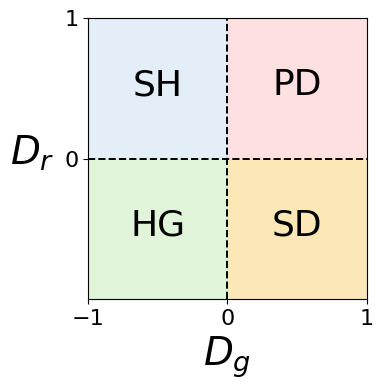

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
import string

# ============================================================
# SHARED PARAMETERS
# ============================================================
N = 2500
w = 0.5
k = 4
timesteps = 120000
c = 1
Dr_arrival = 1
Dg_arrival = 1
lambda_val = 2

pd_bg = '#ffd9d9'
sh_bg = '#dceaf7'
sd_bg = '#fae3a4'
hg_bg = '#d9f2d0'

base_points = [
    (-0.5, 0.75),
    (-0.92, 0.25),
    (-0.8, -0.3),
    (-0.3, -0.8),
    (0.7, 0.35),
    (0.7, -0.7)
]

panel_labels    = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
panel_positions = [(-0.64, 0.75), (-0.92, 0.4), (-0.80, -0.45), (-0.30, -0.93), (0.7, 0.2), (0.72, -0.84)]
# panel_positions = [(-0.92, 0.4), (-0.30, -0.93), (0.72, -0.84), (-0.64, 0.75), (0.7, 0.2), (-0.80, -0.45)]

initial_cooperator_fractions = [0.25, 0.45, 0.8]

# ============================================================
# SHARED HELPER FUNCTIONS
# ============================================================
def equation(rho, Dg, Dr):
    return (
        rho**(lambda_val + 1) * (Dg - Dr + Dr_arrival - Dg_arrival)
        + rho**lambda_val * (Dr - Dr_arrival)
        + rho * (Dr - Dg)
        - Dr
    )

def find_all_roots(Dg, Dr, num_points=300):
    rho_vals = np.linspace(0, 1, num_points)
    f_vals   = [equation(rho, Dg, Dr) for rho in rho_vals]
    roots    = []
    for i in range(len(rho_vals) - 1):
        if np.isnan(f_vals[i]) or np.isnan(f_vals[i + 1]):
            continue
        if f_vals[i] * f_vals[i + 1] < 0:
            try:
                sol = root_scalar(lambda rho: equation(rho, Dg, Dr),
                                  bracket=[rho_vals[i], rho_vals[i + 1]],
                                  method='brentq')
                if sol.converged:
                    root = sol.root
                    if not any(np.isclose(root, r, atol=1e-6) for r in roots):
                        roots.append(root)
            except:
                pass
    return roots

def derivative(rho, Dg, Dr):
    return (
        (lambda_val + 1) * rho**lambda_val * (Dg - Dr + Dr_arrival - Dg_arrival)
        + lambda_val * rho**(lambda_val - 1) * (Dr - Dr_arrival)
        + (Dr - Dg)
    )

def point_color(x, y):
    if x > 0 and y > 0:   return pd_bg
    elif x < 0 and y > 0: return sh_bg
    elif x > 0 and y < 0: return sd_bg
    elif x < 0 and y < 0: return hg_bg
    return 'gray'

def point_color_2(x, y):
    if x > 0 and y > 0:   return '#e41a1c'
    elif x < 0 and y > 0: return '#377eb8'
    elif x > 0 and y < 0: return '#ff7f00'
    elif x < 0 and y < 0: return '#4daf4a'
    return 'gray'

def star_color(Dg_star, Dr_star):
    if Dg_star < 0 and Dr_star > 0:   return 'blue'
    elif Dg_star > 0 and Dr_star < 0: return 'orange'
    else:                              return 'red'

# ============================================================
# PLOT 1: PHASE SPACE
# ============================================================
fig1, ax = plt.subplots(figsize=(4, 4))

ax.fill_between([0,  1],  0, 1, color=pd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0],  0, 1, color=sh_bg, alpha=0.8, zorder=0)
ax.fill_between([0,  1], -1, 0, color=sd_bg, alpha=0.8, zorder=0)
ax.fill_between([-1, 0], -1, 0, color=hg_bg, alpha=0.8, zorder=0)

################

ax.set_xlabel(r"$D_g$", fontsize=28)
ax.set_ylabel(r"$D_r$", fontsize=28, rotation=0, labelpad=5)

ax.yaxis.set_label_coords(-0.2, 0.45)

ax.axhline(0, color='k', linestyle='--', linewidth=1.4)
ax.axvline(0, color='k', linestyle='--', linewidth=1.4)
ax.text( 0.5,  0.52, 'PD', fontsize=26, ha='center', va='center')
ax.text(-0.5,  0.52, 'SH', fontsize=26, ha='center', va='center')
ax.text(-0.5, -0.48, 'HG', fontsize=26, ha='center', va='center')
ax.text( 0.5, -0.48, 'SD', fontsize=26, ha='center', va='center')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.set_xticks([-1, 0, 1])
ax.set_yticks([0, 1])
ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig("game_square.svg", format="svg")
plt.savefig("GSquare.png", format="png", dpi=800, bbox_inches='tight')
plt.show()

from google.colab import files
files.download('game_square.svg')
files.download('GSquare.png')

